In [ ]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
train = pd.read_csv('order_products__train.csv')
prior = pd.read_csv('order_products__prior.csv')

In [ ]:
csvs = [aisles,departments,orders,products,train,prior]
for csv in csvs:
  print("csv name",csv.sample(3))
  print("csv shape",csv.shape)
  print("________________________")

csv name      aisle_id                       aisle
119       120                      yogurt
104       105  doughs gelatins bake mixes
116       117      nuts seeds dried fruit
csv shape (134, 2)
________________________
csv name     department_id  department
12             13      pantry
15             16  dairy eggs
2               3      bakery
csv shape (21, 2)
________________________
csv name          order_id  user_id eval_set  order_number  order_dow  \
2868403   3025588   173048    prior             8          1   
1863022    545627   111814    prior            31          0   
743       2740653       50    prior            65          1   

         order_hour_of_day  days_since_prior_order  
2868403                 16                    26.0  
1863022                 18                     5.0  
743                     13                     6.0  
csv shape (3421083, 7)
________________________
csv name        product_id                                   product_name  aisle_

In [ ]:
prior = prior.merge(orders, on='order_id')

In [ ]:
prior.shape

(32434489, 10)

In [ ]:
prior = prior[prior['eval_set'] == 'prior']

In [ ]:
prior = prior.merge(products, on='product_id')

## feature engineering

In [ ]:
prior.sample(5)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id
1122188,118436,38511,2,1,25313,prior,9,6,17,7.0,1 Ply Paper Towels,54,17
15882346,1675798,29487,4,1,185412,prior,10,2,14,5.0,Roma Tomato,83,4
818293,86606,38456,1,1,99013,prior,17,5,22,7.0,Large Grapefruit,24,4
8708898,919343,1408,21,1,14513,prior,18,5,15,29.0,Mini Cucumbers,123,4
26210043,2764066,24964,2,1,143879,prior,18,0,17,30.0,Organic Garlic,83,4


In [ ]:
user_features = prior.groupby('user_id').agg({
    'order_number': 'max',
    'product_id': 'count',
    'reordered': 'mean'
}).rename(columns={
    'order_number': 'total_orders',
    'product_id': 'total_products',
    'reordered': 'reorder_ratio'
}).reset_index()

In [ ]:
user_features

,user_id,total_orders,total_products,reorder_ratio
0,1,10,59,0.694915
1,2,14,195,0.476923
2,3,12,88,0.625000
3,4,5,18,0.055556
4,5,4,37,0.378378
...,...,...,...,...
206204,206205,3,32,0.250000
206205,206206,67,285,0.473684
206206,206207,16,223,0.587444
206207,206208,49,677,0.707533


In [ ]:
product_features = prior.groupby('product_id').agg({
    'order_id': 'count',
    'reordered': 'mean'
}).rename(columns={
    'order_id': 'product_orders',
    'reordered': 'product_reorder_rate'
}).reset_index()

In [ ]:
product_features

,product_id,product_orders,product_reorder_rate
0,1,1852,0.613391
1,2,90,0.133333
2,3,277,0.732852
3,4,329,0.446809
4,5,15,0.600000
...,...,...,...
49672,49684,9,0.111111
49673,49685,49,0.122449
49674,49686,120,0.700000
49675,49687,13,0.461538


In [ ]:
user_product = prior.groupby(['user_id', 'product_id']).agg({
    'order_id': 'count',
    'reordered': 'sum'
}).rename(columns={
    'order_id': 'up_order_count',
    'reordered': 'up_reorder_count'
}).reset_index()

In [ ]:
user_product

,user_id,product_id,up_order_count,up_reorder_count
0,1,196,10,9
1,1,10258,9,8
2,1,10326,1,0
3,1,12427,10,9
4,1,13032,3,2
...,...,...,...,...
13307948,206209,43961,3,2
13307949,206209,44325,1,0
13307950,206209,48370,1,0
13307951,206209,48697,1,0


In [ ]:
## save all of the in csv
user_features.to_csv('user_features.csv', index=False)
product_features.to_csv('product_features.csv', index=False)
user_product.to_csv('user_product.csv',index=False)

In [ ]:
import pandas as pd
user_features = pd.read_csv('user_features.csv')
product_features = pd.read_csv('product_features.csv')
user_product = pd.read_csv('user_product.csv')

In [ ]:
train = train.merge(orders[['order_id', 'user_id']], on='order_id')

In [ ]:
train = train.merge(user_product, on=['user_id', 'product_id'], how='left')
train = train.merge(user_features, on='user_id', how='left')
train = train.merge(product_features, on='product_id', how='left')

In [ ]:
train.fillna(0, inplace=True)

In [ ]:
print(train.head())
train.shape

   order_id  product_id  add_to_cart_order  reordered  user_id  \
0         1       49302                  1          1   112108   
1         1       11109                  2          1   112108   
2         1       10246                  3          0   112108   
3         1       49683                  4          0   112108   
4         1       43633                  5          1   112108   

   up_order_count  up_reorder_count  total_orders  total_products  \
0             2.0               1.0             3              21   
1             2.0               1.0             3              21   
2             0.0               0.0             3              21   
3             0.0               0.0             3              21   
4             2.0               1.0             3              21   

   reorder_ratio  product_orders  product_reorder_rate  
0       0.428571           163.0              0.619632  
1       0.428571          4472.0              0.713775  
2       0.428571 

(1384617, 12)

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1384617.0,1.706298e+06,989732.648868,1.0,843370.000000,1.701880e+06,2.568023e+06,3.421070e+06
product_id,1384617.0,2.555624e+04,14121.272449,1.0,13380.000000,2.529800e+04,3.794000e+04,4.968800e+04
add_to_cart_order,1384617.0,8.758044e+00,7.423936,1.0,3.000000,7.000000e+00,1.200000e+01,8.000000e+01
reordered,1384617.0,5.985944e-01,0.490183,0.0,0.000000,1.000000e+00,1.000000e+00,1.000000e+00
user_id,1384617.0,1.031128e+05,59487.147887,1.0,51732.000000,1.029330e+05,1.549590e+05,2.062090e+05
up_order_count,1384617.0,3.060776e+00,5.779627,0.0,0.000000,1.000000e+00,3.000000e+00,9.900000e+01
up_reorder_count,1384617.0,2.462182e+00,5.584544,0.0,0.000000,0.000000e+00,2.000000e+00,9.800000e+01
total_orders,1384617.0,1.609141e+01,16.614037,3.0,5.000000,1.000000e+01,2.000000e+01,9.900000e+01
total_products,1384617.0,2.075773e+02,247.880354,3.0,56.000000,1.170000e+02,2.560000e+02,3.638000e+03
reorder_ratio,1384617.0,4.472134e-01,0.208437,0.0,0.285714,4.470588e-01,6.095718e-01,9.895288e-01


In [ ]:
train.to_csv("final_train.csv",index = False)

In [ ]:
train = pd.read_csv("final_train.csv")

In [ ]:
train.sample(3)

,order_id,product_id,add_to_cart_order,reordered,user_id,up_order_count,up_reorder_count,total_orders,total_products,reorder_ratio,product_orders,product_reorder_rate
1213637,2997536,21225,35,0,47842,0.0,0.0,5,148,0.351351,986.0,0.505071
913,2948,17630,3,1,109929,2.0,1.0,33,186,0.489247,6807.0,0.784046
596850,1467944,43712,2,1,8991,1.0,0.0,41,243,0.720165,4320.0,0.405324


In [ ]:
features = [
    #'up_reorder_count',
    'total_orders',
    'total_products',
    'reorder_ratio',
    'product_orders',
    'product_reorder_rate'
]

X = train[features]
y = train['reordered']

In [ ]:
X

,total_orders,total_products,reorder_ratio,product_orders,product_reorder_rate
0,3,21,0.428571,163.0,0.619632
1,3,21,0.428571,4472.0,0.713775
2,3,21,0.428571,23826.0,0.524553
3,3,21,0.428571,97315.0,0.691702
4,3,21,0.428571,653.0,0.477795
...,...,...,...,...,...
1384612,29,325,0.744615,13727.0,0.756538
1384613,29,325,0.744615,234.0,0.568376
1384614,14,30,0.633333,57895.0,0.757837
1384615,14,30,0.633333,20033.0,0.524285


In [ ]:
y

,reordered
0,1
1,1
2,0
3,0
4,1
...,...
1384612,1
1384613,1
1384614,1
1384615,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train

,total_orders,total_products,reorder_ratio,product_orders,product_reorder_rate
525159,15,114,0.552632,469.0,0.628998
421659,32,1218,0.738916,409.0,0.381418
1300544,8,127,0.535433,34209.0,0.731766
314776,5,34,0.029412,1017.0,0.635202
749153,60,538,0.654275,4778.0,0.745919
...,...,...,...,...,...
110268,6,45,0.244444,2696.0,0.563056
259178,3,18,0.166667,3641.0,0.178248
131932,3,16,0.000000,36617.0,0.587432
671155,24,601,0.653910,13833.0,0.693125


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

y_pred = model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

F1 Score: 0.7659892000273417
Precision: 0.7251070346285332
Recall: 0.8117567518622705


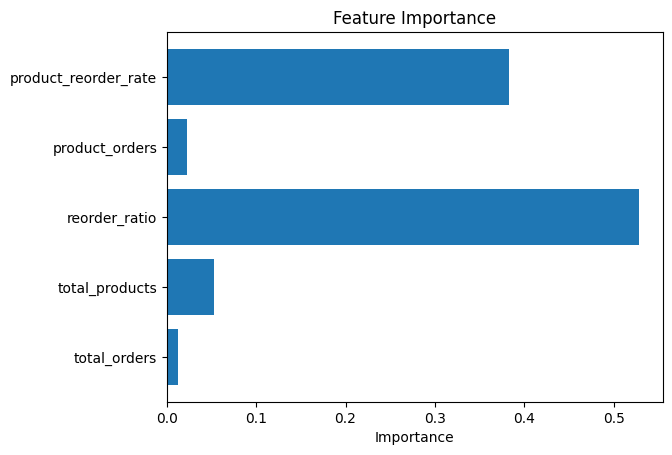

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib
joblib.dump(model,'xgb_model.pkl')

NameError: name 'model' is not defined

In [ ]:
import joblib

In [ ]:
joblib.dump(features,'features.pkl')

['features.pkl']

In [ ]:
model = joblib.load('xgb_model.pkl')
print("Model loaded successfully")

Model loaded successfully


In [ ]:
import numpy as np

In [ ]:
import joblib
model = joblib.load('xgb_model.pkl')
import numpy as np

model.predict(np.array([15, 114, 0.552632, 469.0, 0.628998]).reshape(1, -1))

array([1])